In [1]:
# ============================================================
# Cell 1: Import libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ============================================================
# Cell A: Conceptual framing of this notebook
# ============================================================

## 4f Fourier CNN denoising as an inverse problem

This notebook studies MNIST denoising as a **supervised inverse problem**.

We treat the clean digit as the unknown object \(x\), the noisy measured digit as \(y\), and the learned denoiser as a network that approximates the inverse mapping from \(y\) back to \(x\).

In the language of **Lecture 12**, this follows the supervised inverse-problem pipeline

$$
y_i = A x_i + n
$$

$$
\hat{x}_i = N(y_i)
$$

where  

where

- $A$ is the forward imaging operator  
- $n$ is noise  
- $N(\cdot)$ is the neural network

This is exactly the framework shown in **Lecture 12, page 9**, where paired data, a learned network, and a reconstruction loss are used to recover the object from degraded measurements.

This notebook is also related to **deep optics**, where optics and computation are optimized together rather than separately. **Lecture 15, pages 3–4** contrast traditional imaging pipelines with deep optics systems where the optical front end can be optimized jointly with the downstream neural network.

In [2]:
# ============================================================
# Cell 2: Set random seeds for reproducibility
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# Cell B: Random initialization and reproducibility
# ============================================================

This notebook sets random seeds so that both the **Gaussian noise** and the **initial Fourier mask weights** are reproducible.

This is important because the training process learns a mapping

$$
N(y_i) \approx x_i
$$

from noisy measurements to clean images.

As described in **Lecture 12**, supervised inverse problems depend strongly on

- the training dataset
- the forward model
- the initialization of the reconstruction algorithm.

Reproducibility ensures that experiments comparing architectures, noise levels, or optical masks remain consistent.

In [3]:
# ============================================================
# Cell 3: Load MNIST and normalize to [0,1]
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test  = x_test[..., None]

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)
y_train shape: (60000,)
y_test shape : (10000,)


# ============================================================
# Cell C: Clean MNIST digits as ground truth
# ============================================================

The MNIST digits loaded in the next cell represent the **ground truth objects**

$$
x_i
$$

These images represent the true scene before any corruption or measurement noise.

During training, the network will attempt to reconstruct these images from corrupted observations

$$
y_i
$$

using a learned reconstruction operator

$$
\hat{x}_i = N(y_i)
$$

This matches the supervised learning pipeline described in **Lecture 12**, where the network output is compared against the ground truth image using a loss function.

In [4]:
# ============================================================
# Cell 4: Create noisy MNIST digits
# ============================================================

noise_std = 0.5   # adjust this to make denoising easier/harder

x_train_noisy = x_train + noise_std * np.random.randn(*x_train.shape).astype("float32")
x_test_noisy  = x_test  + noise_std * np.random.randn(*x_test.shape).astype("float32")

# Clip so pixels remain in [0,1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy, 0.0, 1.0)

print("Noisy training min/max:", x_train_noisy.min(), x_train_noisy.max())
print("Noisy test min/max    :", x_test_noisy.min(), x_test_noisy.max())

Noisy training min/max: 0.0 1.0
Noisy test min/max    : 0.0 1.0


# ============================================================
# Cell D: Gaussian noise as part of the forward model
# ============================================================

To simulate a degraded imaging system, Gaussian noise is added to the clean MNIST digits.

This creates a forward model of the form

$$
y = A x + n
$$

where

- \(x\) = clean image
- \(A\) = imaging operator
- \(n\) = measurement noise.

In this simplified experiment the operator \(A\) is approximately the identity operator, while the noise term represents measurement corruption.

This forward model is the same formulation used in **Lecture 12**, where inverse imaging methods attempt to recover the object \(x\) from the measurement \(y\).

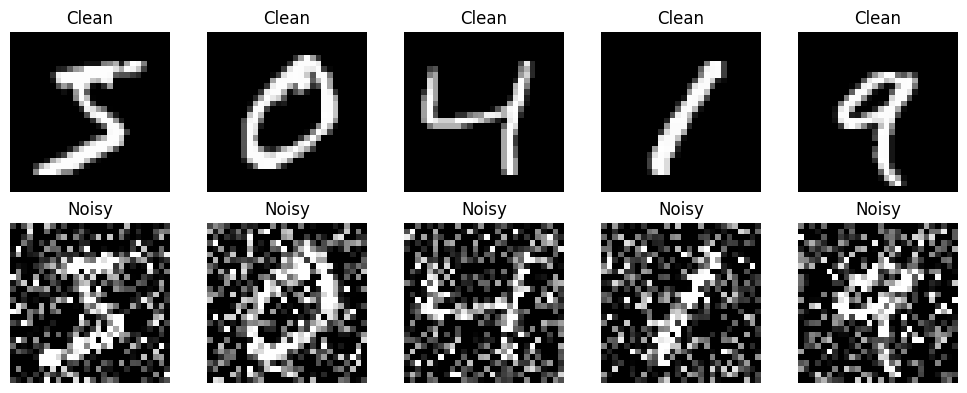

In [5]:
# ============================================================
# Cell 5: Display clean and noisy examples
# ============================================================

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i,:,:,0], cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(2,5,5+i+1)
    plt.imshow(x_train_noisy[i,:,:,0], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Cell E: Visualizing clean and noisy measurements
# ============================================================

Before training the denoising model, it is useful to visualize both

- the clean digits \(x\)
- the noisy measurements \(y\)

so we can understand the difficulty of the reconstruction problem.

In imaging systems, degradation often arises from blur or optical aberrations. In **Lecture 14**, blur is modeled using the **point spread function (PSF)**, which describes how a point in the scene spreads out on the sensor.

Mathematically,

$$
y = x * h
$$

where \(h\) is the PSF.

Although our experiment uses additive noise instead of blur, both forms of degradation motivate the need for computational reconstruction methods.

In [6]:
# ============================================================
# Cell 6: Define 4f Fourier denoising layer
# ============================================================

class OpticalFourierDenoise(layers.Layer):
    """
    4f-inspired denoising layer.

    Input:
        noisy image x(b,h,w,1)

    Pipeline:
        x -> complex field
          -> FFT
          -> multiply by learned Fourier-plane mask
          -> IFFT
          -> output image estimate

    The Fourier-plane mask is directly learned as:
        M = A + iB

    with A and B initialized using RandomNormal(stddev=0.02),
    matching the FCNN-style initialization.

    This is NOT using an LG basis.
    """

    def __init__(self, filters, input_height, input_width,
                 phase_only=True, use_intensity=False, use_I2=False,
                 eps=1e-6, **kwargs):
        super().__init__(**kwargs)

        self.filters = filters
        self.H = input_height
        self.W = input_width
        self.phase_only = phase_only
        self.use_intensity = use_intensity
        self.use_I2 = use_I2
        self.eps = eps

    def build(self, input_shape):
        self.in_channels = int(input_shape[-1])

        self.kernel_real = self.add_weight(
            name="kernel_real",
            shape=(self.in_channels, self.filters, self.H, self.W),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            dtype=tf.float32
        )

        self.kernel_imag = self.add_weight(
            name="kernel_imag",
            shape=(self.in_channels, self.filters, self.H, self.W),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            dtype=tf.float32
        )

    def call(self, inputs):
        # -------------------------------------------------
        # Step 1: Convert input to complex field
        # -------------------------------------------------
        x = tf.cast(inputs, tf.complex64)              # (B,H,W,C)
        x = tf.transpose(x, perm=[0,3,1,2])            # (B,C,H,W)

        # -------------------------------------------------
        # Step 2: FFT -> Fourier plane
        # -------------------------------------------------
        Uf = tf.signal.fft2d(x)                        # (B,C,H,W)

        # -------------------------------------------------
        # Step 3: Build complex learned masks
        # -------------------------------------------------
        mask = tf.complex(self.kernel_real, self.kernel_imag)   # (C,F,H,W)

        power = tf.reduce_mean(tf.abs(mask)**2, axis=[2,3], keepdims=True)
        mask = mask / tf.cast(tf.sqrt(power + self.eps), tf.complex64)

        # Optional phase-only projection
        if self.phase_only:
            phase = tf.math.angle(mask)
            mask = tf.exp(1j * tf.cast(phase, tf.complex64))

        # -------------------------------------------------
        # Step 4: Apply learned mask in Fourier plane
        # -------------------------------------------------
        Uf = Uf[:, :, None, :, :]          # (B,C,1,H,W)
        mask = mask[None, :, :, :, :]      # (1,C,F,H,W)

        Uf_filt = Uf * mask                # (B,C,F,H,W)

        # Sum over input channels
        Uf_filt = tf.reduce_sum(Uf_filt, axis=1)   # (B,F,H,W)

        # -------------------------------------------------
        # Step 5: IFFT -> image plane
        # -------------------------------------------------
        u_out = tf.signal.ifft2d(Uf_filt)          # (B,F,H,W)

        # -------------------------------------------------
        # Step 6: Detection / output formation
        # -------------------------------------------------
        if self.use_intensity:
            y = tf.abs(u_out)**2
            if self.use_I2:
                y = y**2
        else:
            # Better for denoising regression:
            # allow signed/real reconstruction rather than intensity only
            y = tf.math.real(u_out)

        # -------------------------------------------------
        # Step 7: Return channels-last
        # -------------------------------------------------
        y = tf.transpose(tf.cast(y, tf.float32), perm=[0,2,3,1])   # (B,H,W,F)
        return y

# ============================================================
# Cell F: Optical interpretation of the stacked Fourier layers
# ============================================================

The custom layer implemented in this notebook simulates a **4f optical system**.

A classical 4f system performs the transformation

$$
U_f(f_x,f_y) = \mathcal{F}\{u(x,y)\}
$$

followed by multiplication with a Fourier-plane mask

$$
U_{filtered}(f_x,f_y) =
U_f(f_x,f_y) \cdot H(f_x,f_y)
$$

and reconstruction through the inverse transform

$$
u_{out}(x,y) =
\mathcal{F}^{-1}
\left[
U_{filtered}(f_x,f_y)
\right]
$$

In the current model architecture, **two 4f systems are applied sequentially**.  
Each layer learns an independent Fourier-plane mask.

The processing pipeline therefore becomes

$$
u_1(x,y)
=
\mathcal{F}^{-1}
\left[
\mathcal{F}\{u(x,y)\} \cdot H_1(f_x,f_y)
\right]
$$

followed by a second pass

$$
u_2(x,y)
=
\mathcal{F}^{-1}
\left[
\mathcal{F}\{u_1(x,y)\} \cdot H_2(f_x,f_y)
\right]
$$

This results in a **cascaded optical filtering system**

$$
u(x,y)
\rightarrow
\text{4f}_1
\rightarrow
\text{4f}_2
\rightarrow
u_{out}(x,y)
$$

where the masks $H_1$ and $H_2$ are **learned during training**.

Physically, this architecture can be interpreted as two sequential Fourier-plane processing stages, where the output image of the first 4f system becomes the input field of the second system.

This stacked configuration increases model capacity by allowing multiple learned frequency-domain filtering operations before the final reconstruction layer.

In [7]:
# ============================================================
# Cell 7: Build denoising 4f model
# ============================================================

model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    OpticalFourierDenoise(
        filters=1,
        input_height=28,
        input_width=28,
        phase_only=True,
        use_intensity=False,
        use_I2=True
    ),

    OpticalFourierDenoise(
        filters=1,
        input_height=28,
        input_width=28,
        phase_only=True,
        use_intensity=False,
        use_I2=True
    )
])

model.summary()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ optical_fourier_denoise         │ (None, 28, 28, 1)      │         1,568 │
│ (OpticalFourierDenoise)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ optical_fourier_denoise_1       │ (None, 28, 28, 1)      │         1,568 │
│ (OpticalFourierDenoise)         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,136 (12.25 KB)

 Trainable params: 3,136 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ optical_fourier_denoise         │ (None, 28, 28, 1)      │         1,568 │
│ (OpticalFourierDenoise)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ optical_fourier_denoise_1       │ (None, 28, 28, 1)      │         1,568 │
│ (OpticalFourierDenoise)         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,136 (12.25 KB)

 Trainable params: 3,136 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

# ============================================================
# Cell G: Hybrid optical–computational reconstruction
# ============================================================

The full model combines

- a **trainable Fourier optical layer**
- conventional convolutional layers
- a reconstruction output layer.

This creates a hybrid system

$$
x \rightarrow
\text{Optical Layer}
\rightarrow
\text{CNN}
\rightarrow
\hat{x}
$$

which is an example of **deep optics**.

In **Lecture 15**, deep optics refers to systems where both the optical element and the computational processing are optimized together in a single learning framework.

In [8]:
# ============================================================
# Cell 8: Compile model for denoising
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

# ============================================================
# Cell H: Reconstruction loss
# ============================================================

The model is trained using **mean squared error (MSE)**.

The loss function is

$$
L(x_i,\hat{x}_i) =
\frac{1}{N}
\sum
(x_i - \hat{x}_i)^2
$$

where

- $x_i$ = ground truth clean image
- $\hat{x}_i$ is the reconstructed image

This is the same reconstruction loss shown in **Lecture 12, page 10**, where supervised neural networks learn the inverse mapping from measurements to objects.

In [9]:
# ============================================================
# Cell 9: Train the denoising model
# ============================================================

history = model.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0425 - mae: 0.1448 - val_loss: 0.0345 - val_mae: 0.1331
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0345 - mae: 0.1327 - val_loss: 0.0345 - val_mae: 0.1327
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0345 - mae: 0.1327 - val_loss: 0.0345 - val_mae: 0.1325
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0345 - mae: 0.1327 - val_loss: 0.0345 - val_mae: 0.1324
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0345 - mae: 0.1326 - val_loss: 0.0345 - val_mae: 0.1323


# ============================================================
# Cell I: Physical interpretation of training
# ============================================================

During training the model learns the optimal Fourier-plane mask

$$
H(f_x,f_y)
$$

that suppresses noise while preserving useful spatial frequencies.

The learned optical transformation becomes

$$
u_{out}(x,y) =
\mathcal{F}^{-1}
\left[
\mathcal{F}(x) H(f_x,f_y)
\right]
$$

This means the model is effectively learning a **data-driven optical filter**.

In **Lecture 14**, the aperture determines the shape of the blur kernel. In this notebook, the Fourier mask plays a similar role but is optimized automatically through gradient descent.

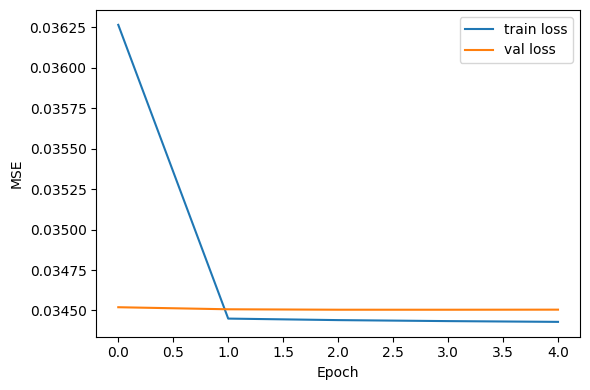

In [10]:
# ============================================================
# Cell 10: Plot training history
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Cell J: Interpreting training curves
# ============================================================

Training curves plot the reconstruction loss over epochs.

Ideally we observe

$$
L_{train} \downarrow
\quad
L_{val} \downarrow
$$

indicating that the learned mapping

$$
\hat{x} = N(y)
$$

is improving.

These curves provide evidence that the model is successfully learning the inverse operator described in **Lecture 12**.

In [11]:
# ============================================================
# Cell 11: Predict denoised images
# ============================================================

x_test_denoised = model.predict(x_test_noisy)

print("Denoised shape:", x_test_denoised.shape)
print("Min:", x_test_denoised.min())
print("Max:", x_test_denoised.max())
print("Mean:", x_test_denoised.mean())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
Denoised shape: (10000, 28, 28, 1)
Min: -0.29745603
Max: 1.0117762
Mean: 0.13183212


# ============================================================
# Cell K: Denoised reconstruction
# ============================================================

After training, the network produces a reconstructed image

$$
\hat{x}
$$

from the noisy input

$$
y
$$

The reconstruction approximates the inverse operator

$$
\hat{x} \approx A^{-1}(y)
$$

as discussed in **Lecture 12**, where neural networks act as learned approximations to inverse imaging operators.

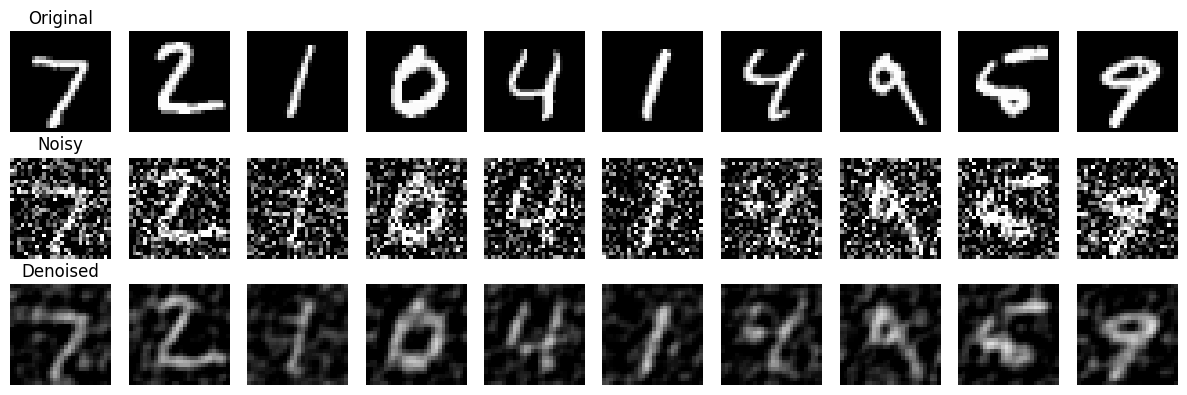

In [12]:
# ============================================================
# Cell 12: Plot original, noisy, and double-pass denoised images
# ============================================================

def plot_images(original, noisy, denoised, n=10):
    plt.figure(figsize=(12, 4))

    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        # Noisy
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Noisy")

        # Double-pass denoised
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(denoised[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Denoised")

    plt.tight_layout()
    plt.show()


plot_images(x_test, x_test_noisy, x_test_denoised, n=10)

# Cell M: Classification-based evaluation of the double-pass 4f denoiser

In addition to reconstruction quality, we evaluate whether the double-pass 4f denoiser preserves digit identity.

To do this, a classifier is trained on clean MNIST and then tested on:

1. clean MNIST
2. noisy MNIST
3. denoised MNIST after two sequential 4f filtering stages

Because the stacked 4f model outputs a single reconstructed image, the denoised result can be passed directly to the classifier without additional channel averaging.

# ============================================================
# Cell L: Inspecting the learned Fourier mask
# ============================================================

Finally, we visualize the learned Fourier-plane mask

$$
H(f_x,f_y)
$$

which acts as a programmable optical filter.

The mask modifies the spatial frequency content of the image

$$
U_{filtered}(f_x,f_y)
=
U(f_x,f_y) H(f_x,f_y)
$$

before reconstruction.

This learned mask can be interpreted as a **data-optimized pupil function**, similar to the coded apertures discussed in **Lecture 14**, but learned automatically from training data.

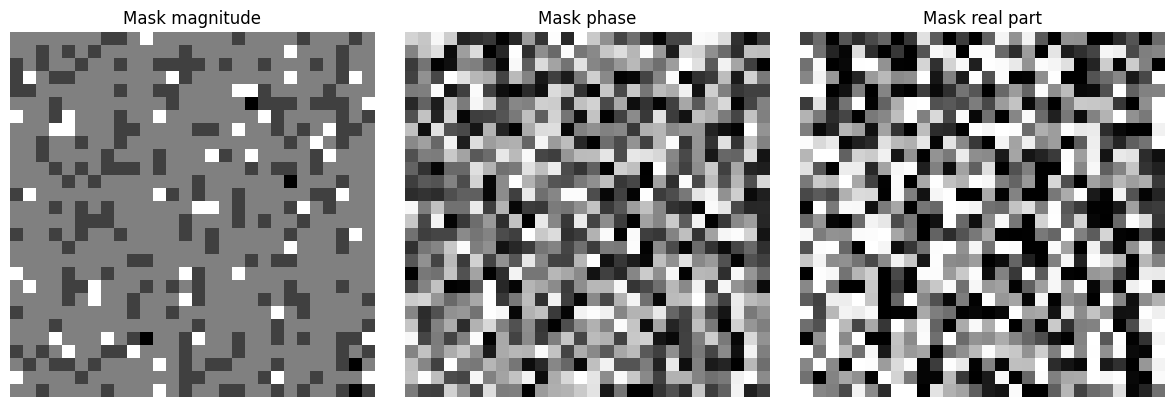

In [13]:
# ============================================================
# Cell 13: Inspect learned Fourier-plane mask
# ============================================================

fourier_layer = None
for layer in model.layers:
    if isinstance(layer, OpticalFourierDenoise):
        fourier_layer = layer
        break

k_real = fourier_layer.kernel_real.numpy()
k_imag = fourier_layer.kernel_imag.numpy()
k_complex = k_real + 1j * k_imag

# First input channel, first output filter
M0 = k_complex[0,0]

# Normalize for plotting
M0 = M0 / np.sqrt(np.mean(np.abs(M0)**2) + 1e-6)

if fourier_layer.phase_only:
    M0_plot = np.exp(1j * np.angle(M0))
else:
    M0_plot = M0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.abs(M0_plot), cmap="gray")
plt.title("Mask magnitude")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.angle(M0_plot), cmap="gray")
plt.title("Mask phase")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.real(M0_plot), cmap="gray")
plt.title("Mask real part")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Cell 14: Define a CNN classifier for MNIST
# ============================================================

def build_classifier():
    inp = Input(shape=(28, 28, 1))

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(10, activation="softmax")(x)

    clf = Model(inp, out)
    clf.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return clf

classifier = build_classifier()
classifier.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================================
# Cell 15: Train classifier on clean MNIST
# ============================================================

clf_history = classifier.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8549 - loss: 0.5013 - val_accuracy: 0.9786 - val_loss: 0.0681
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9817 - loss: 0.0634 - val_accuracy: 0.9824 - val_loss: 0.0569
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9858 - val_loss: 0.0466
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9907 - loss: 0.0323 - val_accuracy: 0.9868 - val_loss: 0.0397
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9926 - loss: 0.0253 - val_accuracy: 0.9897 - val_loss: 0.0327


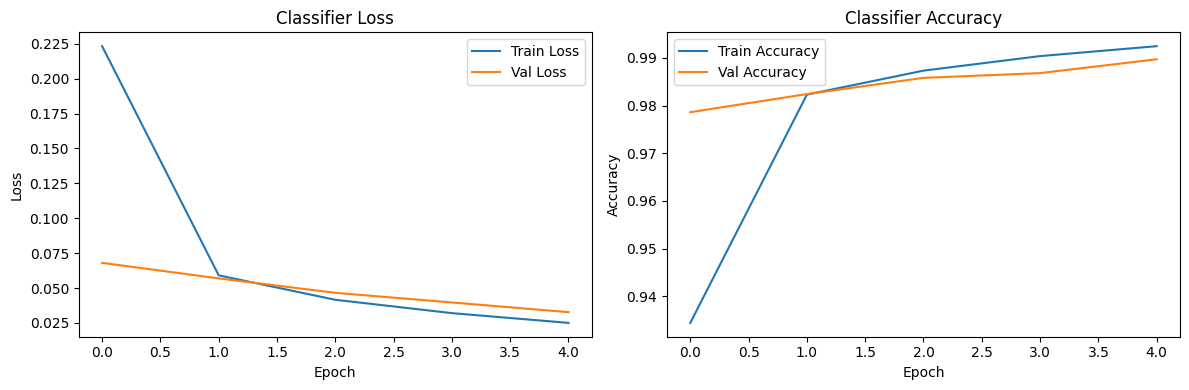

In [16]:
# ============================================================
# Cell 16: Plot classifier training history
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(clf_history.history["loss"], label="Train Loss")
plt.plot(clf_history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clf_history.history["accuracy"], label="Train Accuracy")
plt.plot(clf_history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Cell 17: Evaluate classifier on clean, noisy, and denoised MNIST
# ============================================================

clean_loss, clean_acc = classifier.evaluate(x_test, y_test, verbose=0)
noisy_loss, noisy_acc = classifier.evaluate(x_test_noisy, y_test, verbose=0)
den_loss, den_acc = classifier.evaluate(x_test_denoised, y_test, verbose=0)

print(f"Clean accuracy    : {clean_acc:.4f}")
print(f"Noisy accuracy    : {noisy_acc:.4f}")
print(f"Denoised accuracy : {den_acc:.4f}")

Clean accuracy    : 0.9897
Noisy accuracy    : 0.6342
Denoised accuracy : 0.8771


In [18]:
# ============================================================
# Cell 18: Generate class predictions
# ============================================================

y_pred_clean = np.argmax(classifier.predict(x_test), axis=1)
y_pred_noisy = np.argmax(classifier.predict(x_test_noisy), axis=1)
y_pred_denoised = np.argmax(classifier.predict(x_test_denoised), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [19]:
# ============================================================
# Cell 19: Print classification reports
# ============================================================

print("Classification report: CLEAN")
print(classification_report(y_test, y_pred_clean))

print("\nClassification report: NOISY")
print(classification_report(y_test, y_pred_noisy))

print("\nClassification report: DENOISED")
print(classification_report(y_test, y_pred_denoised))

Classification report: CLEAN
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Classification report: NOISY
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       980
           1       0.86      0.53      0.65      1135
           2       

In [20]:
# ============================================================
# Cell 20: Compute confusion matrices
# ============================================================

cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_noisy = confusion_matrix(y_test, y_pred_noisy)
cm_denoised = confusion_matrix(y_test, y_pred_denoised)

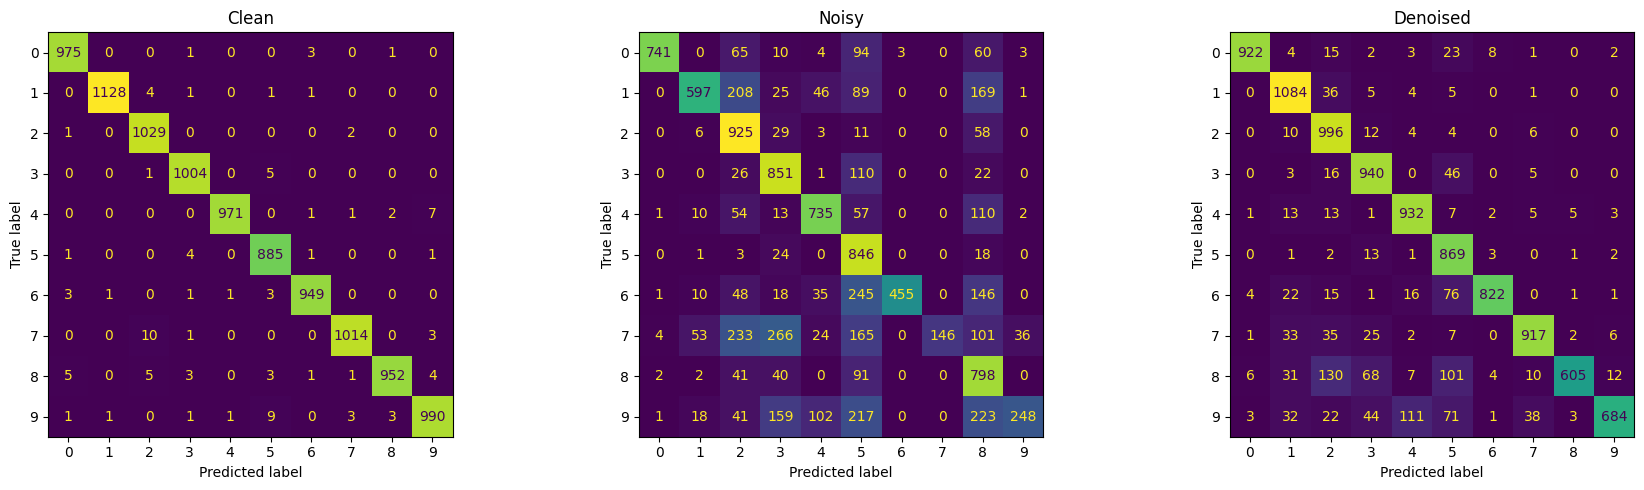

In [21]:
# ============================================================
# Cell 21: Plot confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Clean")

ConfusionMatrixDisplay(cm_noisy).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Noisy")

ConfusionMatrixDisplay(cm_denoised).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Denoised")

plt.tight_layout()
plt.show()

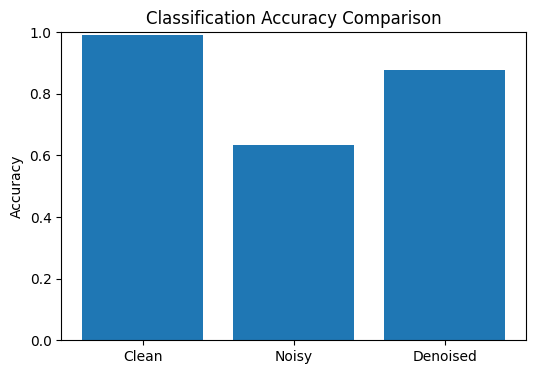

Clean: 0.9897
Noisy: 0.6342
Denoised: 0.8771


In [22]:
# ============================================================
# Cell 22: Compare classification accuracies
# ============================================================

conditions = ["Clean", "Noisy", "Denoised"]
accuracies = [clean_acc, noisy_acc, den_acc]

plt.figure(figsize=(6, 4))
plt.bar(conditions, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Comparison")
plt.show()

for name, acc in zip(conditions, accuracies):
    print(f"{name}: {acc:.4f}")

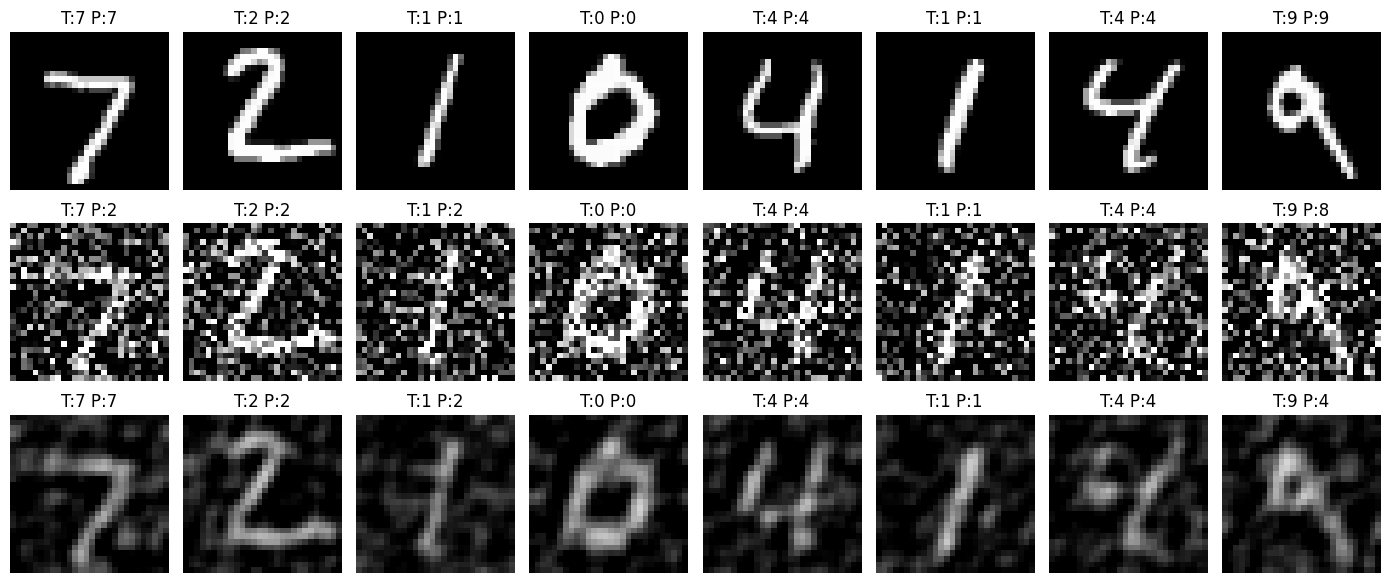

In [23]:
# ============================================================
# Cell 23: Visualize predictions
# ============================================================

n = 8
plt.figure(figsize=(14, 6))

for i in range(n):
    # Clean
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_clean[i]}")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_noisy[i]}")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_denoised[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_denoised[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()